Sequence length: 80
{'A': 21, 'T': 25, 'G': 20, 'C': 14}
Sequence length: 80
GC content: 20.175


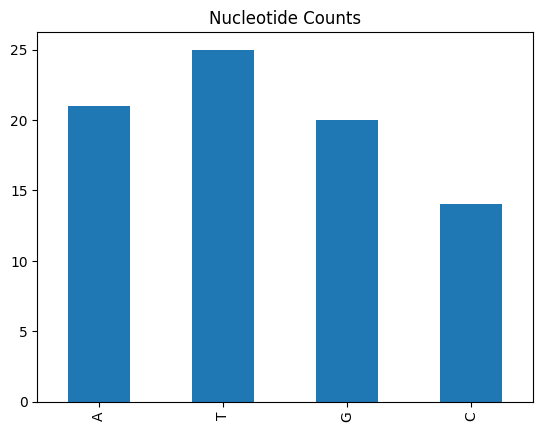

In [1]:
## Single sequence FASTA Analysis

import pandas as pd
from fasta_parser import count_bases_from_fasta

seq,counts = count_bases_from_fasta("test_sequence.fasta")

print("Sequence length:",len(seq))
counts

df = pd.DataFrame.from_dict(counts, orient="index", columns=["count"])
gc = (counts["G"] + counts["C"] / sum(counts.values()))

plot = df.plot(kind="bar", legend=False, title="Nucleotide Counts")
plot
print("GC content:",gc)

,length
TestSequence2,40
TestSequence3,40


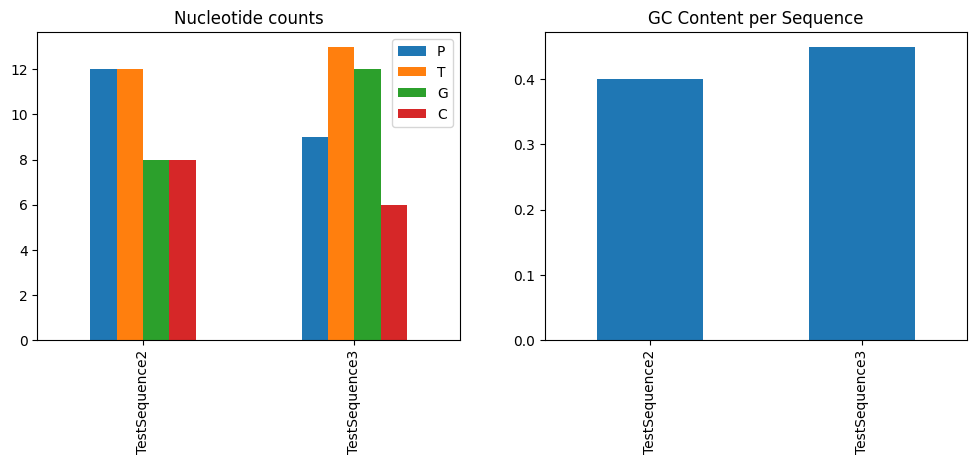

In [ ]:
## Multi FASTA Analysis

import pandas as pd
import matplotlib.pyplot as plt

from multifasta_parser import count_bases_multi,parse_multi_fasta
seqs = parse_multi_fasta("test_sequence.fasta")
results = count_bases_multi(seqs)

df = pd.DataFrame(results).T
dfGC = (df["G"]+df["C"])/df.sum(axis=1)

## Plots

fig, axes = plt.subplots(1,2, figsize=(12,4))
df.plot(kind="bar", ax=axes[0], title=("Nucleotide counts"))
dfGC.plot(kind="bar", ax=axes[1], title=("GC Content per Sequence"))

## Sequence lengths

sequence_lengths = {header:len(seq) for header, seq in seqs.items()}
df1 = pd.DataFrame.from_dict(sequence_lengths, orient="index", columns=["length"])
df1



[np.float64(33.854304635761586), np.float64(28.158940397350992), np.float64(34.615894039735096), np.float64(28.516556291390728), np.float64(34.615894039735096), np.float64(28.516556291390728), np.float64(34.615894039735096), np.float64(34.615894039735096)]


Text(0.5, 1.0, 'Per-read mean quality distribution')

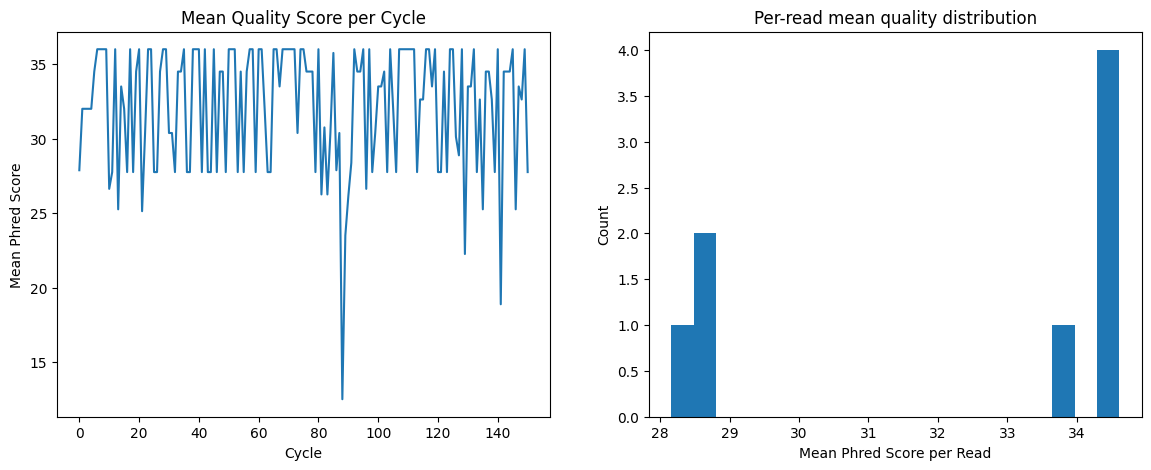

In [7]:
## FASTQ Parsing & Quality Scores
import numpy as np
import matplotlib.pyplot as plt
from itertools import zip_longest
from fastq_parser import parse_fastq,phred_scores

file = "R1.fq"

seqs,quals = parse_fastq(file)
phred_scores(quals[0])

##array synthesis
all_scores = [phred_scores(q) for q in quals]
padded = list(zip_longest(*all_scores, fillvalue=np.nan))
per_cycle = np.array(padded).T
mean_quality = np.nanmean(per_cycle, axis=0)

fig, axes = plt.subplots(1,2,figsize=(14,5))

##plot formation - Mean Quality Score per Cycle 

axes[0].plot(mean_quality)
axes[0].set_title("Mean Quality Score per Cycle")
axes[0].set_xlabel("Cycle")
axes[0].set_ylabel("Mean Phred Score")

PRM = [np.mean(s) for s in all_scores]
print(PRM)

## plot formation - per read mean
axes[1].hist(PRM,bins=20)
axes[1].set_xlabel("Mean Phred Score per Read")
axes[1].set_ylabel("Count")
axes[1].set_title("Per-read mean quality distribution")


[('T', 'T', 'T', 'T', 'T', 'T', 'T', 'C'), ('A', 'A', 'A', 'A', 'A', 'A', 'A', 'C'), ('C', 'G', 'C', 'G', 'C', 'G', 'C', 'C'), ('A', 'G', 'A', 'G', 'A', 'G', 'A', 'C'), ('A', 'A', 'A', 'A', 'A', 'A', 'A', 'C'), ('A', 'G', 'A', 'G', 'A', 'G', 'A', 'C'), ('A', 'G', 'A', 'G', 'A', 'G', 'A', 'C'), ('T', 'C', 'T', 'C', 'T', 'C', 'T', 'C'), ('G', 'T', 'G', 'T', 'G', 'T', 'G', 'C'), ('C', 'T', 'C', 'T', 'C', 'T', 'C', 'C'), ('A', 'G', 'A', 'G', 'A', 'G', 'A', 'A'), ('C', 'G', 'C', 'G', 'C', 'G', 'C', 'C'), ('A', 'A', 'A', 'A', 'A', 'A', 'A', 'A'), ('T', 'G', 'T', 'G', 'T', 'G', 'T', 'T'), ('C', 'T', 'C', 'T', 'C', 'T', 'C', 'C'), ('G', 'A', 'G', 'A', 'G', 'A', 'G', 'G'), ('C', 'C', 'C', 'C', 'C', 'C', 'C', 'C'), ('T', 'C', 'T', 'C', 'T', 'C', 'T', 'T'), ('G', 'A', 'G', 'A', 'G', 'A', 'G', 'G'), ('A', 'A', 'A', 'A', 'A', 'A', 'A', 'A'), ('A', 'T', 'A', 'T', 'A', 'T', 'A', 'A'), ('A', 'A', 'A', 'A', 'A', 'A', 'A', 'A'), ('G', 'A', 'G', 'A', 'G', 'A', 'G', 'G'), ('G', 'T', 'G', 'T', 'G', 'T', 'G

Text(0, 0.5, 'GC%')

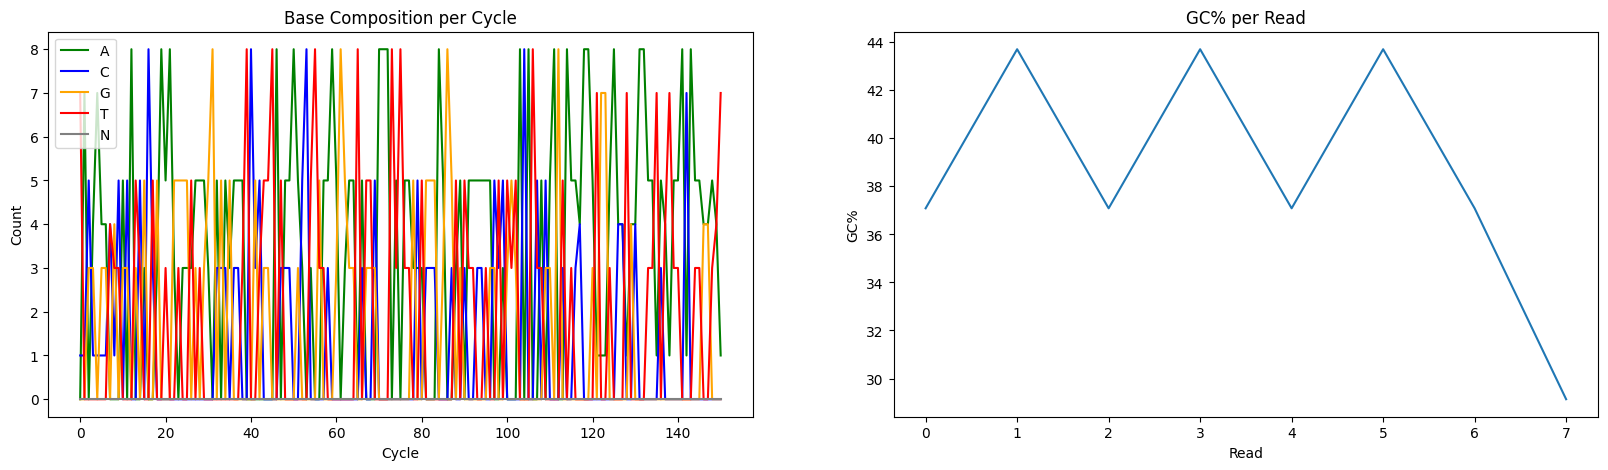

In [8]:
## Base Composition per Cycle

from fastq_parser import base_comp_per_cycle,gc_computation,parse_fastq
import matplotlib.pyplot as plt

file = ("R1.fq")

## Base composition 

results = base_comp_per_cycle(file)

A = [cycle["A"] for cycle in results]
C = [cycle["C"] for cycle in results]
G = [cycle["G"] for cycle in results]
T = [cycle["T"] for cycle in results]
N = [cycle["N"] for cycle in results]

cycles = range(len(results))

## GC per read

seq,qual = parse_fastq(file)
gcpercentage = gc_computation(seq)
print(gcpercentage)

## Base composition plot 

fig,axes = plt.subplots(1,2, figsize=(20,5))

axes[0].plot(cycles, A, label="A", color="green")
axes[0].plot(cycles, C, label="C", color="blue")
axes[0].plot(cycles, G, label="G", color="orange")
axes[0].plot(cycles, T, label="T", color="red")
axes[0].plot(cycles, N, label="N", color="grey")

axes[0].set_title("Base Composition per Cycle")
axes[0].set_xlabel("Cycle")
axes[0].set_ylabel("Count")
axes[0].legend()

## GC per read plot

axes[1].plot(gcpercentage)
axes[1].set_title("GC% per Read")
axes[1].set_xlabel("Read")
axes[1].set_ylabel("GC%")



Text(0, 0.5, 'N%')

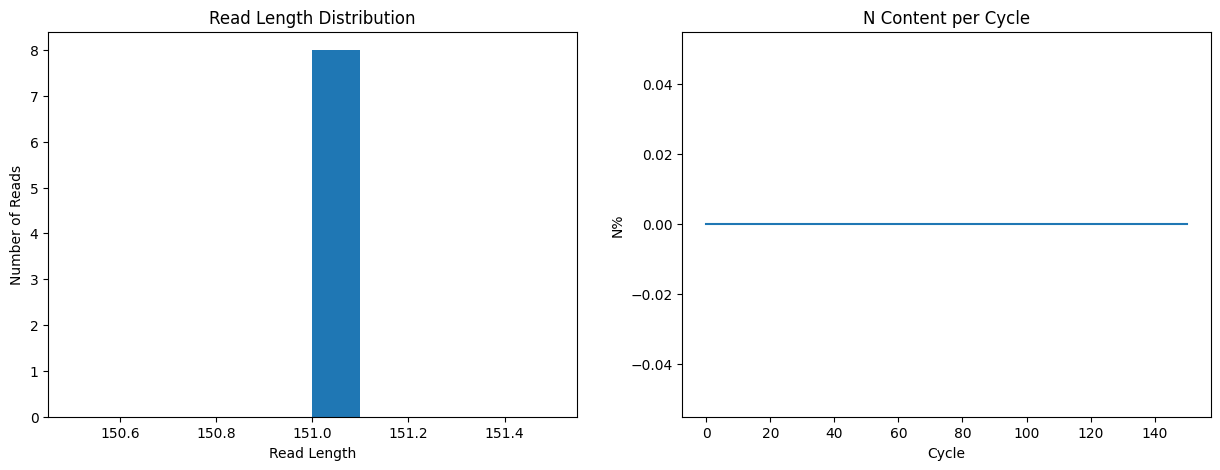

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from fastq_parser import parse_fastq
from read_structure_content_biases import read_length_distribution,n_content_per_cycle

## Read length distribution

seq,qual = parse_fastq("R1.fq")
seqlens = read_length_distribution(seq)

## N content per cycle

ncont = n_content_per_cycle(seq)

fig,axes = plt.subplots(1,2,figsize=(15,5))

axes[0].hist(seqlens)
axes[0].set_title("Read Length Distribution")
axes[0].set_xlabel("Read Length")
axes[0].set_ylabel("Number of Reads")

axes[1].plot(ncont)
axes[1].set_title("N Content per Cycle")
axes[1].set_xlabel("Cycle")
axes[1].set_ylabel("N%")

In [1]:
from fastq_parser import parse_fastq
from read_structure_content_biases import overrepresented_sequences, k_mer_content
import pandas as pd
from collections import Counter

## Overrespresented Sequences

seq,qual = parse_fastq("R1.fq")
dfors= overrepresented_sequences(seq)
print(dfors.to_string(index=False))

## Kmer Content
print("")
dfkmer,counts = k_mer_content(seq)
print(dfkmer.to_string(index=False))



 Rank     Sequence  Percentage Incidence
    1 AAACAAAGGATT                  50.0
    2 TTACATTAATAT                  37.5
    3 AAAAAAAAAAAA                  12.5
    4   ACAAAGGATT                  50.0
    5   ACATTAATAT                  37.5
    6   AAAAAAAAAA                  12.5
    7     AAAGGATT                  50.0
    8     ATTAATAT                  37.5
    9     AAAAAAAA                  12.5

K-mer  Count  Percentage Incidence(%) Flags
TACAA      4                 0.340136     *
ACAAA     12                 1.020408     *
CAAAA      8                 0.680272     *
AAAAT     11                 0.935374     *
AAATG      8                 0.680272     *
AATGC      4                 0.340136     *
ATGCA      4                 0.340136     *
TGCAC      4                 0.340136     *
GCACA      4                 0.340136     *
CACAT      5                 0.425170     *
ACATC     10                 0.850340     *
CATCG      5                 0.425170     *
ATCGC     10    

In [11]:
## Adapter Candidates
from fastq_parser import parse_fastq
from read_structure_content_biases import adapter_candidates, sequence_trimming
import pandas as pd
import numpy as np
file = "R1.fq"

seqs, qual = parse_fastq(file)
adapter_candidates1 = adapter_candidates(seqs)
print("Adapter Candidates:", adapter_candidates1)
print(seqs)
print("")

## Trimming

adapters = ["ACGTACGTACGT", "TTGACCGT", "GATCTAGCTA"]

trimmed_seqs, trimmed_quals, lengths_removed = sequence_trimming(seqs,qual,adapter_candidates1)


df = pd.DataFrame(trimmed_seqs, columns=["Trimmed Sequences"])
df["Trimmed Qualities"] = trimmed_quals
print(df.to_string(index=False))

## Trimming Report

total_reads = len(seqs)

trimmed_reads = 0
total_bases_removed = 0
adapter_types = []

for original, trimmed in zip(seqs, trimmed_seqs):

    removed = len(original) - len(trimmed)

    if removed > 0:
        trimmed_reads += 1
        total_bases_removed += removed

        adapter = original[len(trimmed):]
        adapter_types.append(adapter)

adapter_types = list(dict.fromkeys(adapter_types))

if trimmed_reads > 0:
    avg_trim = total_bases_removed / trimmed_reads
else:
    avg_trim = 0

print("")
print("-----------------")
print("")
print("Total Reads:", total_reads)
print("Number of reads trimmed:", trimmed_reads)
print("Total bases removed:", total_bases_removed)
print("Adapter types Detected:", adapter_types)
print("Average trimmed bases per trimmed read:", avg_trim)

## Please find bug disclosure in README

Adapter Candidates: []
['TACAAAATGCACATCGCTGAAAGGGGTAAAGGAGAGAAATCGCTTTATAAAACCTTGAAAAGGAATATTCAAATATAAGCTGGGAAGGTATAAAAAACTCTGTACATCACAAGTAAACAAATGGAACCTGCAAAATATTAAACAAAGGATT', 'TAGGAGGCTTGGAGTACCAATAATAAAGTGAGCCCACCTTCCTGGTACCCAGACATTTCAGGAGGTCGGGAAATTTTTAAACCCAGGCAGCTTCCTGGCAGTGACATTTGGAGCATCAAAGTGGTAAATAAAATTTCATTTACATTAATAT', 'TACAAAATGCACATCGCTGAAAGGGGTAAAGGAGAGAAATCGCTTTATAAAACCTTGAAAAGGAATATTCAAATATAAGCTGGGAAGGTATAAAAAACTCTGTACATCACAAGTAAACAAATGGAACCTGCAAAATATTAAACAAAGGATT', 'TAGGAGGCTTGGAGTACCAATAATAAAGTGAGCCCACCTTCCTGGTACCCAGACATTTCAGGAGGTCGGGAAATTTTTAAACCCAGGCAGCTTCCTGGCAGTGACATTTGGAGCATCAAAGTGGTAAATAAAATTTCATTTACATTAATAT', 'TACAAAATGCACATCGCTGAAAGGGGTAAAGGAGAGAAATCGCTTTATAAAACCTTGAAAAGGAATATTCAAATATAAGCTGGGAAGGTATAAAAAACTCTGTACATCACAAGTAAACAAATGGAACCTGCAAAATATTAAACAAAGGATT', 'TAGGAGGCTTGGAGTACCAATAATAAAGTGAGCCCACCTTCCTGGTACCCAGACATTTCAGGAGGTCGGGAAATTTTTAAACCCAGGCAGCTTCCTGGCAGTGACATTTGGAGCATCAAAGTGGTAAATAAAATTTCATTTACATTAATAT', 'TACAAAATGCACATCGCTGAAAGGGGTAAAGGAGAGAAATCGCTT